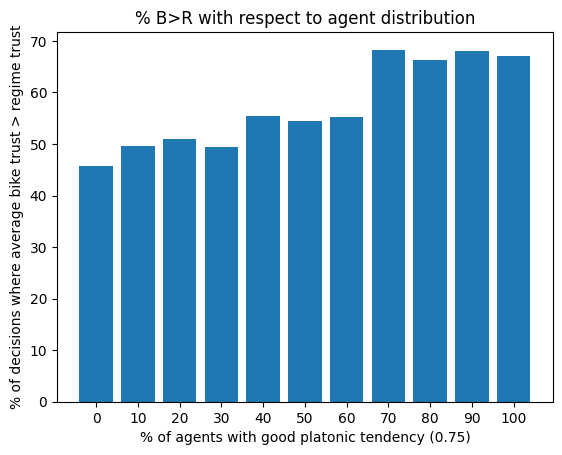

In [3]:
import matplotlib.pyplot as plt
import subprocess

goodpt = 0.75   # controls the bimodal distribution
values = []
N = 10  # number of runs per value of goodagproportion


for i in range(11):
    goodagproportion = i / 10.0 # to get 0.0, 0.1, 0.2 etc
    total = 0

    for j in range(N):
        command = f"go run main.go -goodpt={goodpt} -goodagproportion={goodagproportion}"
        result = subprocess.run(command, shell=True, capture_output=True, text=True)
        percent_b_over_r = float(result.stdout)
        total += percent_b_over_r

    average = total / N
    values.append(average)

# percent of agents with "good" platonic tendency
labels = ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']


plt.bar(labels, values)
plt.xlabel(f"% of agents with good platonic tendency ({goodpt})")
plt.ylabel(f"% of decisions where average bike trust > regime trust")
plt.title(f"% B>R with respect to agent distribution")
plt.show()
